# Insurence prediction project

## Importing the libraries

In [78]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 

warnings.filterwarnings('ignore')

In [79]:
import numexpr
print(numexpr.__version__)


2.10.1


### import csv

In [80]:
df = pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## EDA 

data shape

In [81]:
df.shape

(1338, 7)

data head

In [82]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


data tail

In [83]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


data info

In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


describe

In [85]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


find null

In [86]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [87]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

## Data Visualization

This section creates various plots to understand the distribution and relationships in the data. Visualization is crucial for exploratory data analysis (EDA) to identify patterns, outliers, and data characteristics before applying machine learning models.

The following visualizations will be created:
- Distribution plots for numeric features to see their spread and shape
- Count plots for categorical variables to see frequency distributions
- Box plots to identify outliers in numeric data
- Correlation heatmap to see how features relate to each other

diagrams

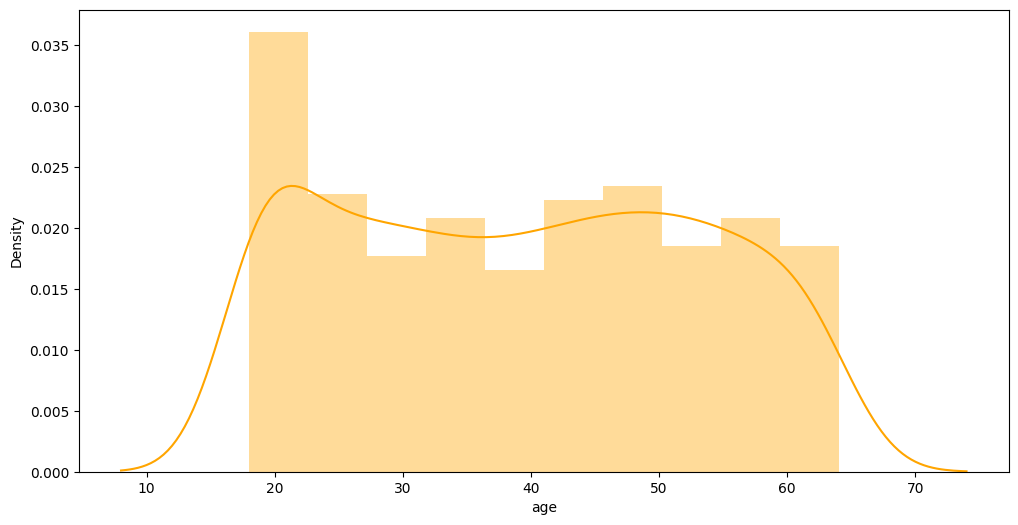

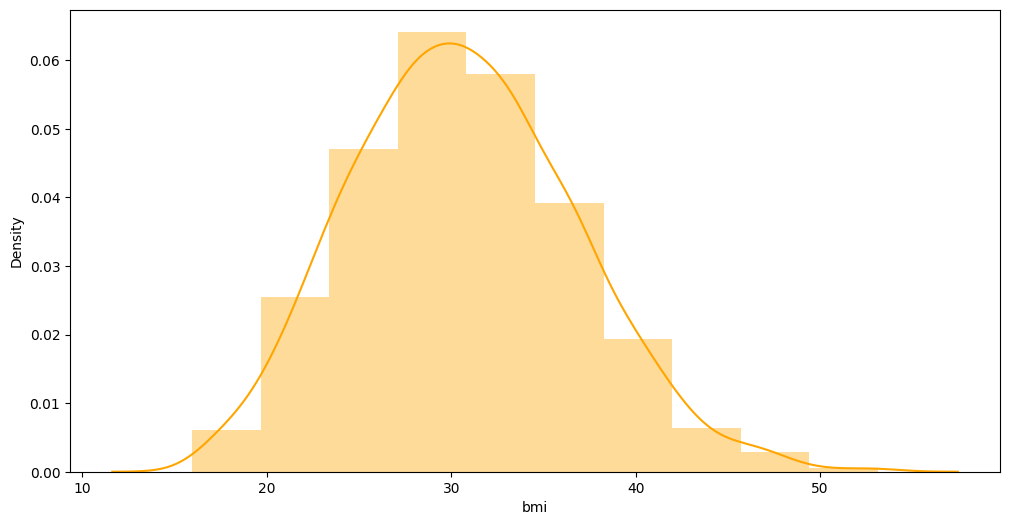

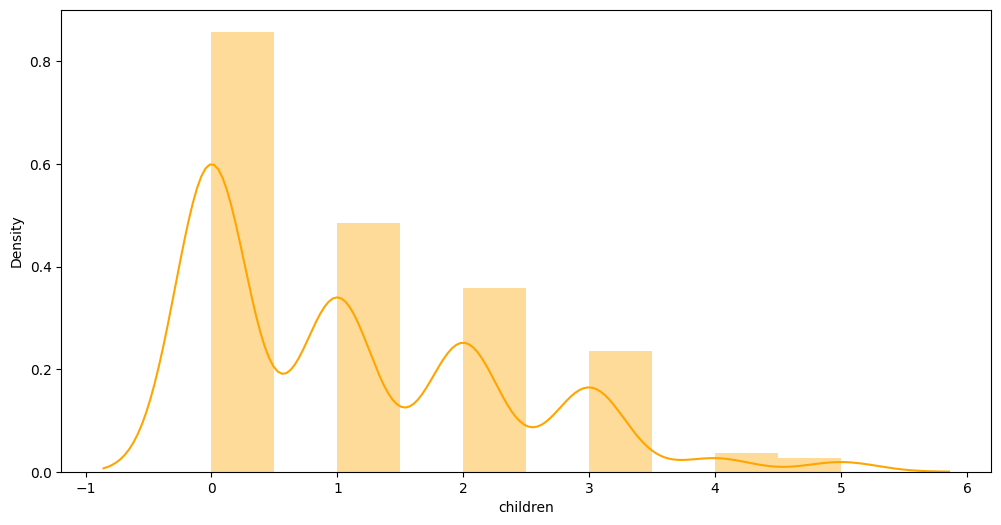

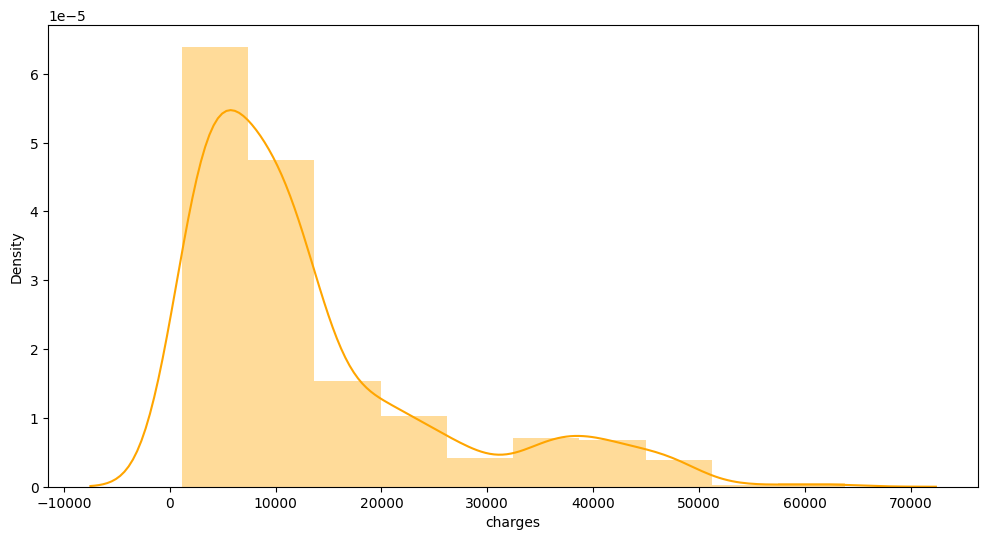

In [88]:
numeric_columns = ['age', 'bmi', 'children', 'charges']
for col in numeric_columns:
    plt.figure(figsize=(12,6))
    sns.distplot(df[col], kde=True, color='orange', bins= 10)

<Axes: xlabel='sex', ylabel='count'>

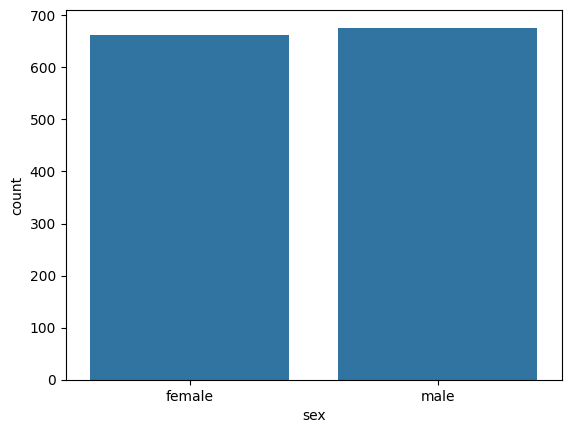

In [89]:
sns.countplot(x = df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

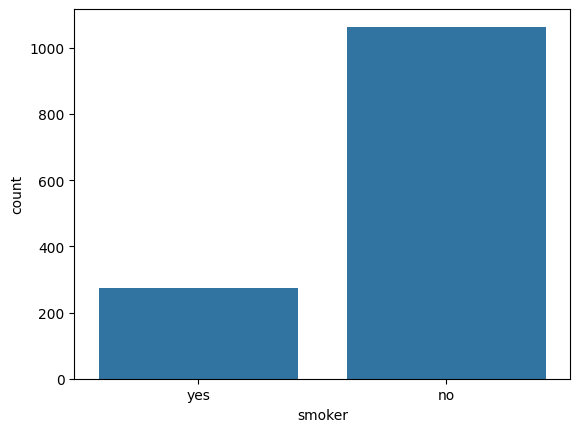

In [90]:
sns.countplot(x = df['smoker'])

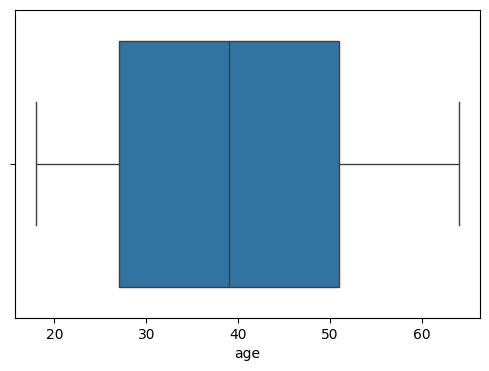

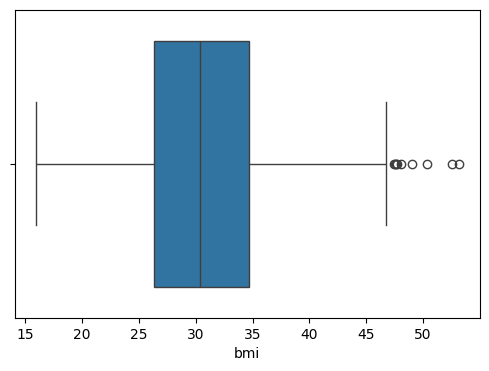

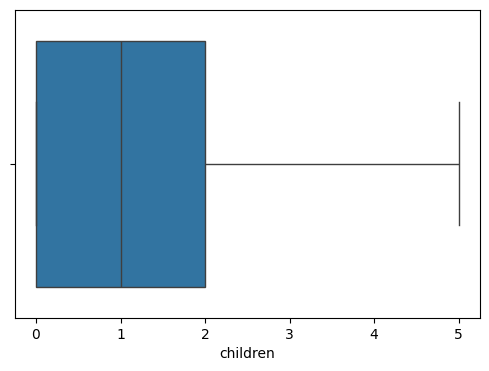

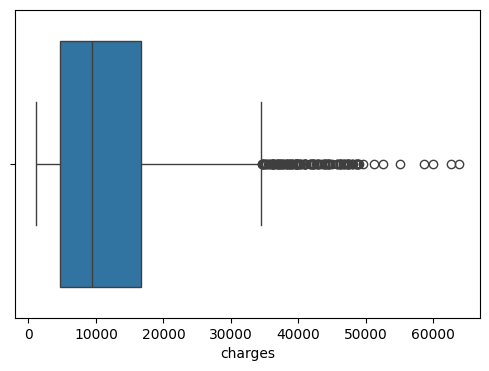

In [91]:
for col in numeric_columns:
    plt.figure(figsize= (6,4))
    sns.boxplot(x = df[col])

<Axes: >

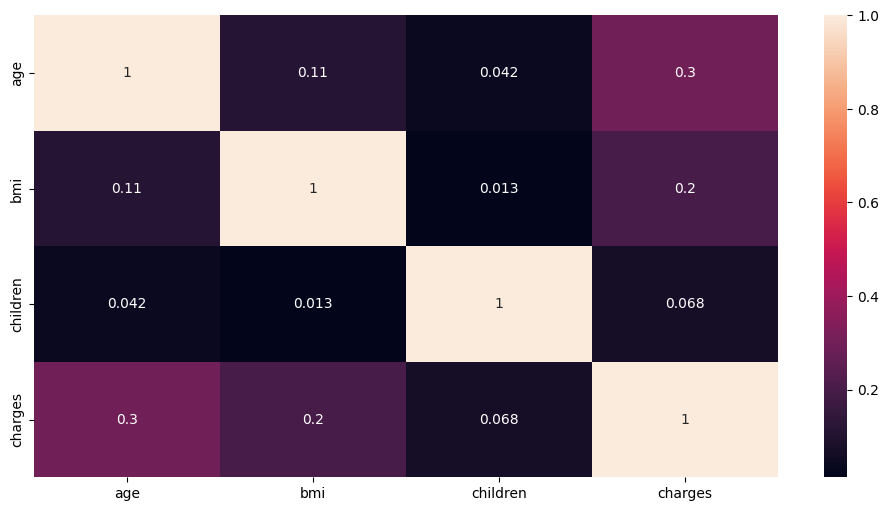

In [92]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

## Data Cleaning and preprocessing

In [93]:
dfc = df.copy()
dfc

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## Data Inspection and Cleaning Preparation

Before cleaning the data, we need to understand its structure. This involves checking:
- Data shape: number of rows and columns
- Data types: whether columns are numeric, object, or other types
- Missing values: null or NaN values that need handling
- Duplicate rows: repeated records that should be removed

The code checks these aspects to plan the cleaning strategy.

In [94]:
dfc.info

<bound method DataFrame.info of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

In [95]:
dfc.dtypes


age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [96]:
dfc.drop_duplicates(inplace=True)

## Categorical Variable Encoding

Machine learning models require numeric inputs, but some features are categorical (text values like 'male', 'female', 'yes', 'no'). We convert these to numeric values using mapping:

```python
# Map categorical values to 0 and 1
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})
```

This creates a binary numeric representation where:
- 0 represents one category (e.g., 'male' or 'no')
- 1 represents the other category (e.g., 'female' or 'yes')

In [97]:
dfc.shape

(1337, 7)

In [98]:
dfc.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [99]:
dfc['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [100]:
dfc['sex'] = dfc['sex'].map({'male':0, 'female':1})

In [101]:
dfc.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [102]:
dfc['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [103]:
dfc['smoker'] = dfc['smoker'].map({'no':0, 'yes':1})
dfc.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [104]:
dfc.rename(columns={'sex':'is_female', 'smoker':'is_smoker'}, inplace=True)

In [105]:
dfc.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [106]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [107]:
dfc = pd.get_dummies(dfc,columns=['region'], drop_first=True)

## One-Hot Encoding for Multi-Class Categorical Variables

The 'region' feature has more than 2 categories (northeast, northwest, southeast, southwest). We use one-hot encoding to convert it to multiple binary columns:

```python
df = pd.get_dummies(df, columns=['region'], drop_first=True)
```

This creates separate boolean columns for each region:
- region_northeast: 1 if northeast, 0 otherwise
- region_northwest: 1 if northwest, 0 otherwise
- region_southeast: 1 if southeast, 0 otherwise
- (region_southwest is dropped to avoid multicollinearity)

Each row has exactly one 1 and the rest 0s, representing the actual region.

In [108]:
dfc.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [109]:
dfc = dfc.astype('int')
dfc.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


## Feature Engineering and Extraction

<Axes: xlabel='bmi', ylabel='Count'>

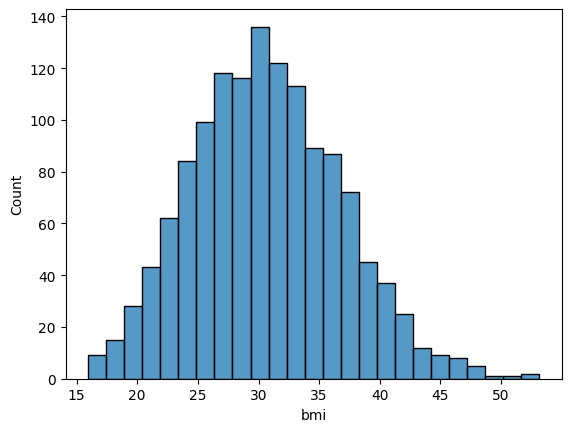

In [110]:
sns.histplot(df['bmi'])

<Axes: xlabel='bmi', ylabel='Count'>

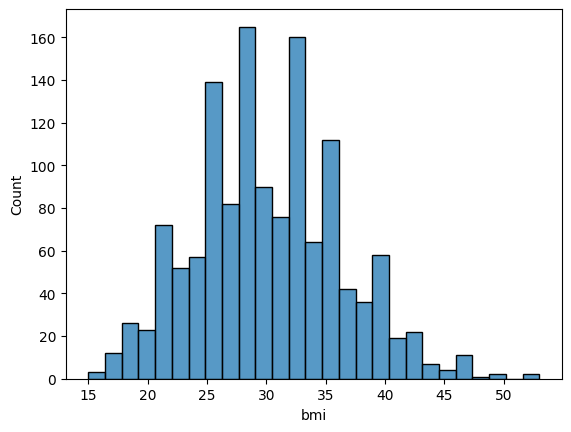

In [111]:
sns.histplot(dfc['bmi'])

In [112]:
dfc['bmi_category']=pd.cut(dfc['bmi'],bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

## Creating BMI Categories

Instead of treating BMI as a continuous variable, we can create meaningful categories based on medical standards:

```python
df['bmi_category'] = pd.cut(
    df['bmi'],
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)
```

The BMI ranges are:
- Underweight: BMI < 18.5
- Normal: 18.5 to 24.9
- Overweight: 25 to 29.9
- Obese: 30 and above

These categories capture the non-linear relationship between BMI and health risk, which can improve model performance.

In [113]:
dfc.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,Normal
4,32,0,28,0,0,3866,1,0,0,Overweight


In [114]:
dfc = pd.get_dummies(dfc,columns=['bmi_category'], drop_first=True)
dfc.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,1,0,False,False,True
3,33,0,22,0,0,21984,1,0,0,True,False,False
4,32,0,28,0,0,3866,1,0,0,False,True,False


In [115]:
dfc = dfc.astype('int')
dfc.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [116]:
dfc.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'],
      dtype='str')

In [117]:
from sklearn.preprocessing import StandardScaler
cols= ['age', 'bmi', 'children']
scaler = StandardScaler()
dfc[cols] = scaler.fit_transform(dfc[cols])
dfc.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


## Feature Scaling Using StandardScaler

Feature scaling normalizes numeric features to have mean=0 and standard deviation=1. This is important because:

```python
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])
```

Why scaling matters:
- Machine learning algorithms perform better when features are on similar scales
- Gradient descent converges faster with scaled features
- Distance-based algorithms (KNN, K-Means) are sensitive to feature magnitudes
- Features like 'age' (0-100) and 'charges' (1000-60000) need to be on same scale

After scaling, all features have mean≈0 and standard deviation≈1, preventing larger-scale features from dominating.

extraction

In [118]:
from scipy.stats import pearsonr

# List of features to check against target
selected_features = [
    'age', 'bmi', 'children', 'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

correlations = {
    feature: pearsonr(dfc[feature], dfc['charges'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
4,is_smoker,0.787234
0,age,0.298309
10,bmi_category_Obese,0.200348
1,bmi,0.196236
6,region_southeast,0.073577
2,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
3,is_female,-0.058046
8,bmi_category_Normal,-0.104042


## Pearson Correlation Analysis for Feature Importance

Pearson correlation measures the linear relationship between each feature and the target variable (charges), ranging from -1 to +1:

```python
from scipy.stats import pearsonr
correlation = pearsonr(feature, target)
```

Interpreting correlation values:
- r close to +1: Strong positive correlation (high feature → high target)
- r close to 0: Weak or no correlation
- r close to -1: Strong negative correlation (high feature → low target)

For insurance charges:
- 'is_smoker': Likely high positive correlation (smokers pay more)
- 'age': Likely positive correlation (older people pay more)
- 'children': May have weak correlation

Features with weak correlation might be less useful for prediction.

In [119]:
cat_features = [
    'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

In [120]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

dfc['charges_bin'] = pd.qcut(dfc['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(dfc[col], dfc['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
is_smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
is_female,10.258784,0.01649,Reject Null (Keep Feature)
bmi_category_Obese,8.515711,0.036473,Reject Null (Keep Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_category_Overweight,4.25149,0.235557,Accept Null (Drop Feature)
bmi_category_Normal,3.708088,0.29476,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


## Chi-Square Test for Categorical Feature Importance

Chi-square test determines if categorical features are statistically related to the target variable. It tests the null hypothesis that the features are independent:

```python
from scipy.stats import chi2_contingency
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
```

Interpretation:
- p_value < 0.05: Reject null hypothesis → Feature IS related to target (important feature)
- p_value >= 0.05: Accept null hypothesis → Feature may NOT be related to target (less important)

The contingency table is built from the frequency of feature-target combinations. Features with small p-values should be kept in the model as they have strong predictive power.

In [121]:
final_df = dfc[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges','region_southeast','bmi_category_Obese']]

## Final Feature Selection

Based on correlation analysis and chi-square tests, we select only the most important features:

```python
final_df = df[['age', 'is_female', 'bmi', 'children', 'is_smoker', 
                'charges', 'region_southeast', 'bmi_category_Obese']]
```

This reduces:
- Dimensionality: Fewer features mean simpler models
- Computation time: Less data to process
- Overfitting risk: Models with fewer features generalize better
- Interpretability: Easier to understand which features drive predictions

The selected features have shown the strongest statistical relationships with the target variable (insurance charges).

In [122]:
final_df

,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,1,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0


---

In [156]:
from sklearn.model_selection import train_test_split

In [196]:
x= final_df.drop(['charges'],axis=1)

In [197]:
y = final_df[['charges']]

In [198]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [199]:
from sklearn.linear_model import LinearRegression

In [200]:
model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [201]:
y_pred = model.predict(x_test)

In [202]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test,y_pred)

r2

0.8040712413347118

In [204]:
n=x_test.shape[0]
p=x_test.shape[1]
adjusted_r2 = 1-((1-r2)*(n-1)/(n-p-1))

adjusted_r2

0.7987962362937232